
# Análisis Exploratorio de Datos - Cáncer de Mama



/tmp/ipykernel_10687/3114628516.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'B':0, 'M':1})


   diagnosis  radius1  texture1  perimeter1   area1  smoothness1  \
0          1    17.99     10.38      122.80  1001.0      0.11840   
1          1    20.57     17.77      132.90  1326.0      0.08474   
2          1    19.69     21.25      130.00  1203.0      0.10960   
3          1    11.42     20.38       77.58   386.1      0.14250   
4          1    20.29     14.34      135.10  1297.0      0.10030   
5          1    12.45     15.70       82.57   477.1      0.12780   
6          1    18.25     19.98      119.60  1040.0      0.09463   
7          1    13.71     20.83       90.20   577.9      0.11890   
8          1    13.00     21.82       87.50   519.8      0.12730   
9          1    12.46     24.04       83.97   475.9      0.11860   

   compactness1  concavity1  concave_points1  symmetry1  ...  radius3  \
0       0.27760     0.30010          0.14710     0.2419  ...    25.38   
1       0.07864     0.08690          0.07017     0.1812  ...    24.99   
2       0.15990     0.19740     

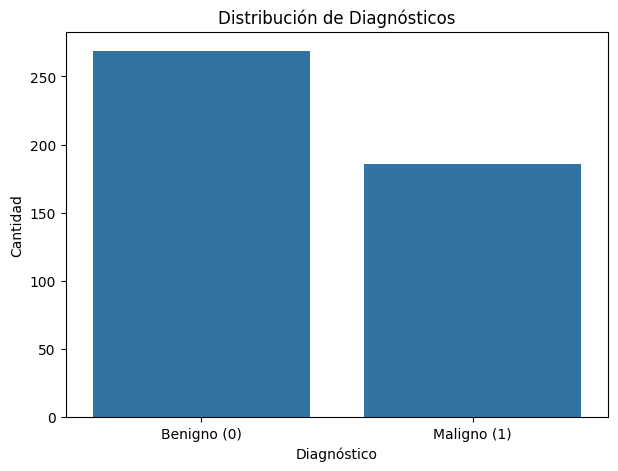

diagnosis
0    269
1    186
Name: count, dtype: int64


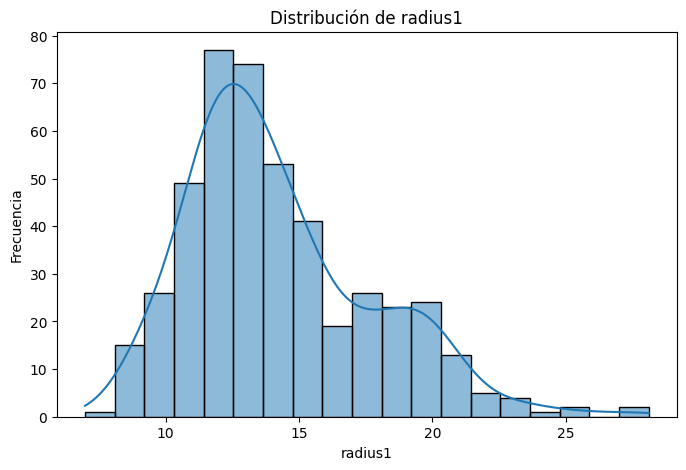

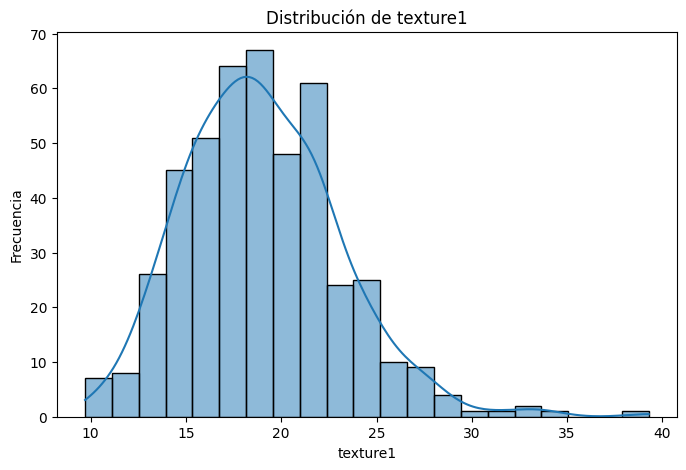

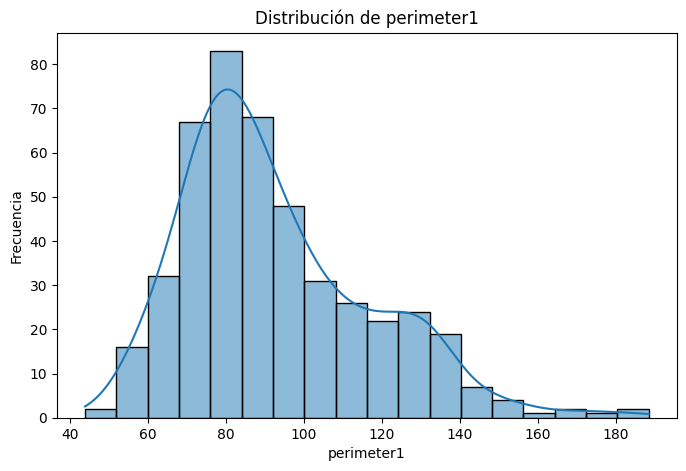

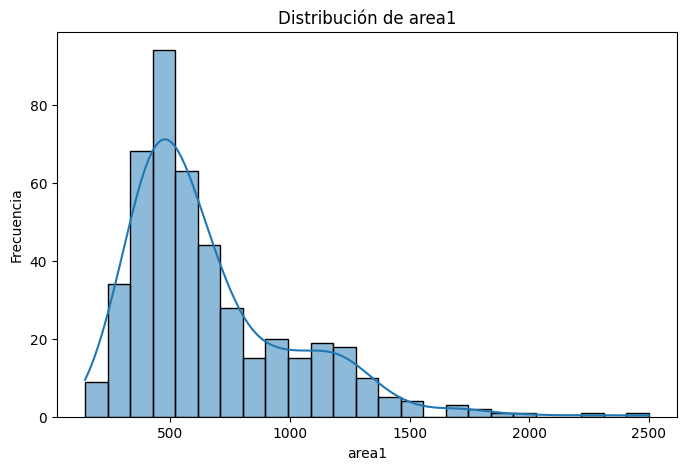

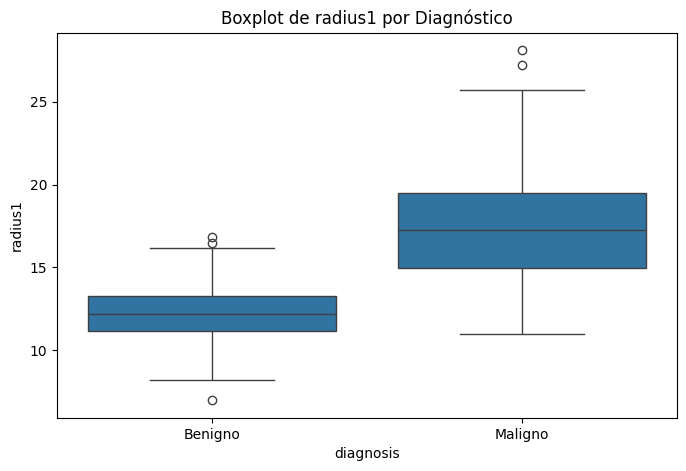

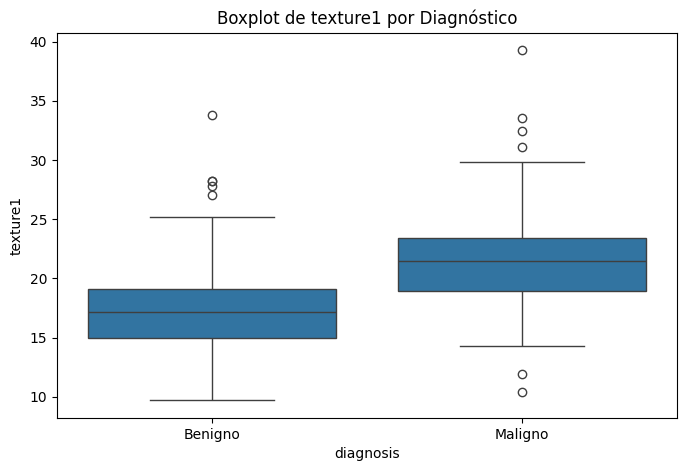

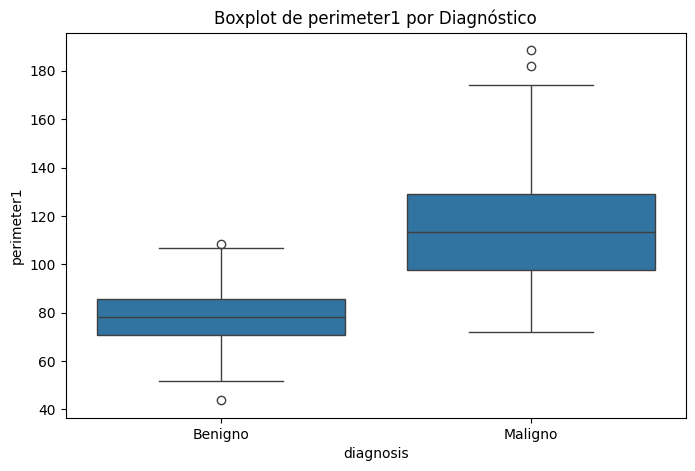

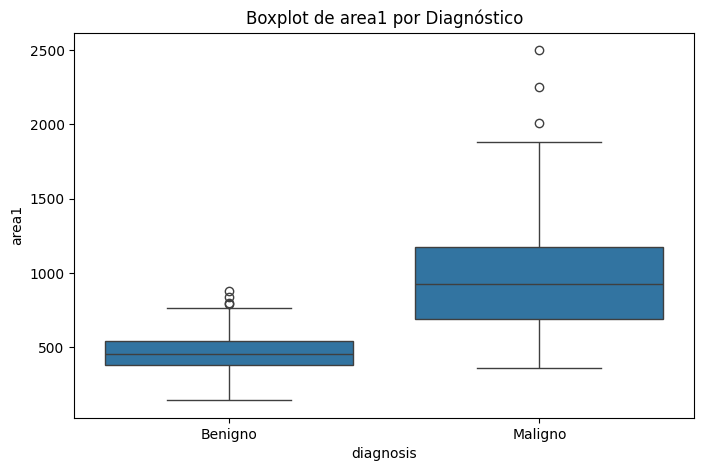

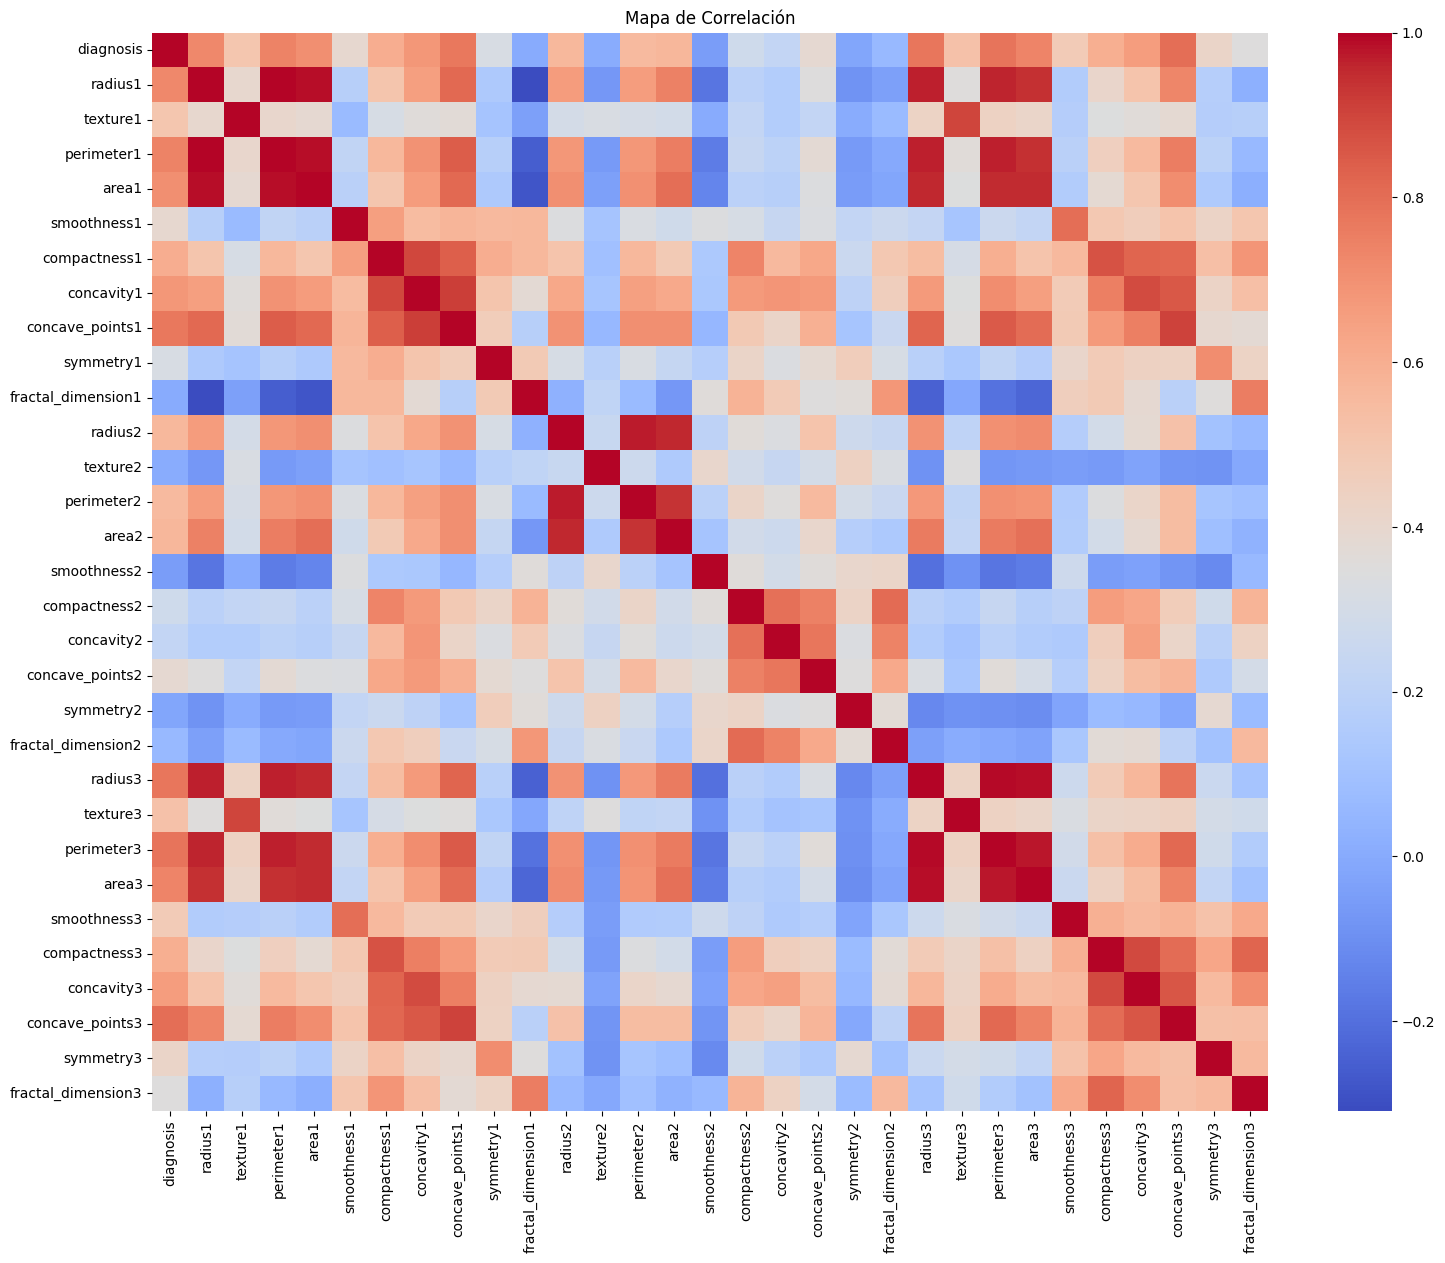

diagnosis          1.000000
concave_points3    0.800212
perimeter3         0.784807
radius3            0.777265
concave_points1    0.770923
perimeter1         0.740257
area3              0.734534
radius1            0.727111
area1              0.704369
concavity1         0.680258
Name: diagnosis, dtype: float64


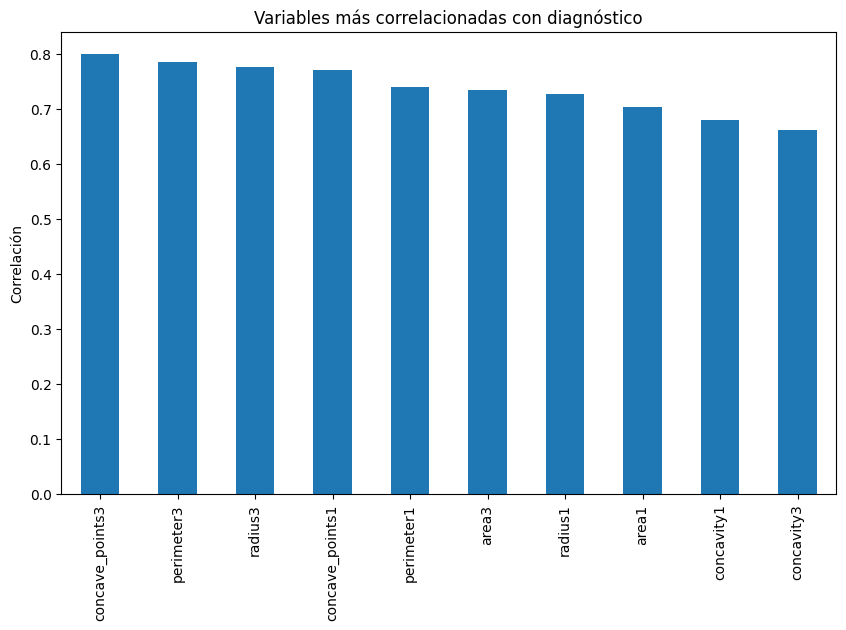

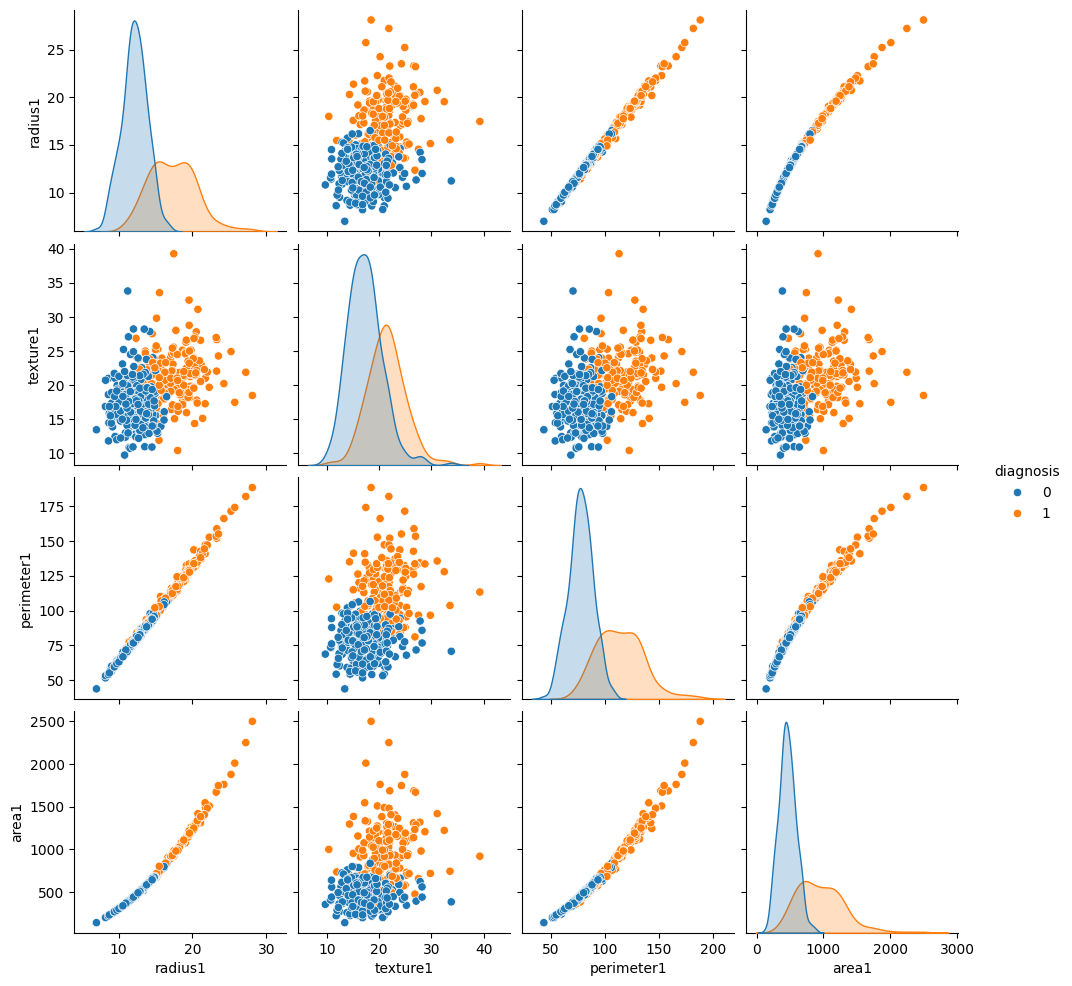

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.rcParams['figure.figsize'] = (10,6)

# Cargar dataset de entrenamiento
df = pd.read_csv('wdbc_train.csv')

# Conversión de diagnóstico
df['diagnosis'] = df['diagnosis'].replace({'B':0, 'M':1})

# Eliminar columna ID
df = df.drop(['id'], axis=1)

# Visualizar primeras filas
print(df.head(10))



# Dimensiones
print("Dimensiones del dataset:")
print(df.shape)

# Información general
print("\nInformación general:")
print(df.info())

# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())



print(df.describe())



plt.figure(figsize=(7,5))

sns.countplot(data=df, x='diagnosis')

plt.xticks([0,1], ['Benigno (0)', 'Maligno (1)'])

plt.title('Distribución de Diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Cantidad')

plt.show()

print(df['diagnosis'].value_counts())



variables = ['radius1', 'texture1', 'perimeter1', 'area1']

for variable in variables:

    plt.figure(figsize=(8,5))

    sns.histplot(data=df, x=variable, kde=True)

    plt.title(f'Distribución de {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frecuencia')

    plt.show()



variables = ['radius1', 'texture1', 'perimeter1', 'area1']

for variable in variables:

    plt.figure(figsize=(8,5))

    sns.boxplot(data=df, x='diagnosis', y=variable)

    plt.xticks([0,1], ['Benigno', 'Maligno'])

    plt.title(f'Boxplot de {variable} por Diagnóstico')

    plt.show()



# Matriz de correlación
correlation = df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(correlation, cmap='coolwarm')

plt.title('Mapa de Correlación')

plt.show()



corr_diagnosis = correlation['diagnosis'].sort_values(ascending=False)

print(corr_diagnosis.head(10))

plt.figure(figsize=(10,6))

corr_diagnosis[1:11].plot(kind='bar')

plt.title('Variables más correlacionadas con diagnóstico')
plt.ylabel('Correlación')

plt.show()



variables_pairplot = ['diagnosis', 'radius1', 'texture1', 'perimeter1', 'area1']

sns.pairplot(df[variables_pairplot], hue='diagnosis')

plt.show()
